# Decision Trees and Ensembles


## Forest cover prediction

Predicting forest cover type, the predominant kind of tree cover, from cartographic variables alone rather than remotely sensed data. Seven classes:

1. Spruce/Fir
2. Lodgepole Pine
3. Ponderosa Pine
4. Cottonwood/Willow
5. Aspen
6. Douglas-fir
7. Krummholz

> "Predicting forest cover type from cartographic variables only (no remotely sensed data). The actual forest cover type for a given observation (30 x 30 meter cell) was determined from US Forest Service (USFS) Region 2 Resource Information System (RIS) data. Independent variables were derived from data originally obtained from US Geological Survey (USGS) and USFS data. Data is in raw form (not scaled) and contains binary (0 or 1) columns of data for qualitative independent variables (wilderness areas and soil types)."
> — [UCI Covertype](https://archive.ics.uci.edu/ml/datasets/covertype)

The dataset is 581,012 observations with 54 features, loaded directly through `sklearn.datasets.fetch_covtype()`. Four classifiers are compared on it: a single decision tree, bagging, AdaBoost, and a random forest, each tuned by grid search on a held-out validation set before a single test evaluation.


In [26]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
import numpy as np

In [27]:
covtype = datasets.fetch_covtype()
X = covtype.data
Y = covtype.target

In [28]:
X.shape, Y.shape

((581012, 54), (581012,))

In [29]:
np.random.seed(0)
perm = np.random.permutation(581012)
trainx = X[perm[0:49500],:]
trainy = Y[perm[0:49500]]
valx = X[perm[49500:55000],:]
valy = Y[perm[49500:55000]]
testx = X[perm[55000:581012],:]
testy = Y[perm[55000:581012]]

In [30]:
sum(trainy==1), sum(trainy==2), sum(trainy==3), sum(trainy==4), sum(trainy==5), sum(trainy==6), sum(trainy==7)

(np.int64(17945),
 np.int64(24251),
 np.int64(3023),
 np.int64(254),
 np.int64(786),
 np.int64(1481),
 np.int64(1760))

### Evaluation protocol

For each classifier: the best validation result, the hyper-parameter values that produced it, and the resulting test accuracy. The test set is scored once, after the hyper-parameters are fixed on validation.

The split is deliberately unusual: 49,500 training, 5,500 validation, and 526,012 test. Holding back the overwhelming majority of the data for testing means the test numbers below are estimated on half a million examples, so they carry very little sampling noise.


## 1. Decision tree


### Training and hyper-parameter tuning


In [12]:
from sklearn.tree import DecisionTreeClassifier
from itertools import product
from sklearn.metrics import accuracy_score
# training and hyper-parameter tuning

# search space for the decision tree
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 10, 50],
    "min_samples_leaf": [1, 5, 10]
}

best_val_acc = 0.0
best_params = None
best_tree = None

# grid search using the validation set
for criterion, max_depth, min_samples_split, min_samples_leaf in product(
    param_grid["criterion"],
    param_grid["max_depth"],
    param_grid["min_samples_split"],
    param_grid["min_samples_leaf"]
):
    tree = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=0
    )
    
    # train on the training set
    tree.fit(trainx, trainy)
    
    # evaluate on the validation set
    val_pred = tree.predict(valx)
    val_acc = accuracy_score(valy, val_pred)

    # info print for this setting
    print(
        f"val_acc = {val_acc:.4f} | "
        f"criterion={criterion}, max_depth={max_depth}, "
        f"min_samples_split={min_samples_split}, "
        f"min_samples_leaf={min_samples_leaf}"
    )
    
    # keep the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = {
            "criterion": criterion,
            "max_depth": max_depth,
            "min_samples_split": min_samples_split,
            "min_samples_leaf": min_samples_leaf
        }
        best_tree = tree

print("Best validation accuracy:", best_val_acc)
print("Best hyperparameters:", best_params)

val_acc = 0.8351 | criterion=gini, max_depth=None, min_samples_split=2, min_samples_leaf=1
val_acc = 0.8242 | criterion=gini, max_depth=None, min_samples_split=2, min_samples_leaf=5
val_acc = 0.8133 | criterion=gini, max_depth=None, min_samples_split=2, min_samples_leaf=10
val_acc = 0.8244 | criterion=gini, max_depth=None, min_samples_split=10, min_samples_leaf=1
val_acc = 0.8242 | criterion=gini, max_depth=None, min_samples_split=10, min_samples_leaf=5
val_acc = 0.8133 | criterion=gini, max_depth=None, min_samples_split=10, min_samples_leaf=10
val_acc = 0.7984 | criterion=gini, max_depth=None, min_samples_split=50, min_samples_leaf=1
val_acc = 0.7975 | criterion=gini, max_depth=None, min_samples_split=50, min_samples_leaf=5
val_acc = 0.7964 | criterion=gini, max_depth=None, min_samples_split=50, min_samples_leaf=10
val_acc = 0.7684 | criterion=gini, max_depth=10, min_samples_split=2, min_samples_leaf=1
val_acc = 0.7695 | criterion=gini, max_depth=10, min_samples_split=2, min_samples_l

### Test


In [13]:
#test
from sklearn.metrics import accuracy_score

# evaluate the best tree on the test set
test_pred = best_tree.predict(testx)
test_acc = accuracy_score(testy, test_pred)

print("Test accuracy of the best decision tree:", test_acc)

Test accuracy of the best decision tree: 0.8336977103183958


1. The best result on the validation set:

    The best validation accuracy achieved by the decision tree classifier is 0.8365.


2. Hyperparameter values for the classifier:
    The best model uses the following settings:

   
        - criterion = 'gini'
        - max_depth = 30
        - min_samples_split = 2
        - min_samples_leaf = 1

    
  
4. The result on the test set:

  

   Using the best decision tree from validation, the accuracy on the test set is 0.8337.

   

**Observations:**

    The validation and test accuracies are very close to each other (around 83–84%), which suggests that the chosen hyperparameters lead to a model that generalizes reasonably well and does not severely overfit the training data. A relatively deep tree (max_depth = 30) with small min_samples_split and min_samples_leaf allows the classifier to capture detailed patterns in the Covertype features, but the similar performance on validation and test sets indicates that the added complexity is still controlled for this dataset.


## 2. Bagging


### Training and hyper-parameter tuning


In [21]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from itertools import product
# training and hyper-parameter tuning

# base learner for bagging
base_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=0
)

param_grid = {
    "n_estimators": [20, 40, 60],
    "max_samples": [0.5, 0.8, 1.0],
    "max_features": [0.5, 0.8, 1.0],
    "bootstrap": [True, False]
}

best_val_acc = 0.0
best_params = None
best_bagging = None

for n_estimators, max_samples, max_features, bootstrap in product(
    param_grid["n_estimators"],
    param_grid["max_samples"],
    param_grid["max_features"],
    param_grid["bootstrap"]
):
    model = BaggingClassifier(
        estimator=base_tree,          # changed from base_estimator to estimator
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        bootstrap=bootstrap,
        n_jobs=-1,
        random_state=0
    )
    
    model.fit(trainx, trainy)

    val_pred = model.predict(valx)
    val_acc = accuracy_score(valy, val_pred)

    print(
        f"val_acc = {val_acc:.4f} | "
        f"n_estimators={n_estimators}, max_samples={max_samples}, "
        f"max_features={max_features}, bootstrap={bootstrap}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = {
            "n_estimators": n_estimators,
            "max_samples": max_samples,
            "max_features": max_features,
            "bootstrap": bootstrap
        }
        best_bagging = model

print("\nBest validation accuracy (Bagging):", best_val_acc)
print("Best hyperparameters (Bagging):", best_params)

val_acc = 0.8342 | n_estimators=20, max_samples=0.5, max_features=0.5, bootstrap=True
val_acc = 0.8425 | n_estimators=20, max_samples=0.5, max_features=0.5, bootstrap=False
val_acc = 0.8724 | n_estimators=20, max_samples=0.5, max_features=0.8, bootstrap=True
val_acc = 0.8838 | n_estimators=20, max_samples=0.5, max_features=0.8, bootstrap=False
val_acc = 0.8695 | n_estimators=20, max_samples=0.5, max_features=1.0, bootstrap=True
val_acc = 0.8838 | n_estimators=20, max_samples=0.5, max_features=1.0, bootstrap=False
val_acc = 0.8462 | n_estimators=20, max_samples=0.8, max_features=0.5, bootstrap=True
val_acc = 0.8613 | n_estimators=20, max_samples=0.8, max_features=0.5, bootstrap=False
val_acc = 0.8789 | n_estimators=20, max_samples=0.8, max_features=0.8, bootstrap=True
val_acc = 0.9011 | n_estimators=20, max_samples=0.8, max_features=0.8, bootstrap=False
val_acc = 0.8887 | n_estimators=20, max_samples=0.8, max_features=1.0, bootstrap=True
val_acc = 0.8962 | n_estimators=20, max_samples=0

### Test


In [22]:
#test
from sklearn.metrics import accuracy_score

test_pred = best_bagging.predict(testx)
test_acc = accuracy_score(testy, test_pred)

print("Test accuracy of the best bagging model:", test_acc)

Test accuracy of the best bagging model: 0.9047036949727383


1. The best result on the validation set:
   
   The bagging classifier reaches a validation accuracy of 0.9075, which is noticeably higher than the single decision tree.

   
3. Hyperparameter values for the classifier:
   
    The best bagging model uses:

        - n_estimators = 60
        - max_samples = 0.8
        - max_features = 0.8
        - bootstrap = False
    
3. The result on the test set:


    With these hyperparameters, the accuracy on the test set is 0.9047.


**Observations:**

    Bagging improves the performance over a single decision tree by aggregating many trees trained on different subsets of the data and features, which reduces variance and stabilizes predictions on unseen examples. The close match between validation and test accuracies indicates that the ensemble generalizes well and that using 60 trees with 80% of the samples and features per estimator provides a strong and robust model for this dataset.


## 3. AdaBoost


### Training and hyper-parameter tuning


In [31]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from itertools import product
# training and hyper-parameter tuning

# weak learner for AdaBoost
base_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=1,
    random_state=0
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.1, 0.5, 1.0]
}

best_val_acc = 0.0
best_params = None
best_ada = None

for n_estimators, learning_rate in product(
    param_grid["n_estimators"],
    param_grid["learning_rate"]
):
    model = AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        algorithm="SAMME",   
        random_state=0
    )
    
    model.fit(trainx, trainy)

    val_pred = model.predict(valx)
    val_acc = accuracy_score(valy, val_pred)

    print(
        f"val_acc = {val_acc:.4f} | "
        f"n_estimators={n_estimators}, learning_rate={learning_rate}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = {
            "n_estimators": n_estimators,
            "learning_rate": learning_rate
        }
        best_ada = model

print("\nBest validation accuracy (AdaBoost):", best_val_acc)
print("Best hyperparameters (AdaBoost):", best_params)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


val_acc = 0.6262 | n_estimators=50, learning_rate=0.1


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


val_acc = 0.6625 | n_estimators=50, learning_rate=0.5


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


...

val_acc = 0.6631 | n_estimators=200, learning_rate=0.1


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


val_acc = 0.6564 | n_estimators=200, learning_rate=0.5


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


val_acc = 0.5876 | n_estimators=200, learning_rate=1.0

Best validation accuracy (AdaBoost): 0.6696363636363636
Best hyperparameters (AdaBoost): {'n_estimators': 100, 'learning_rate': 0.5}


### Test


In [32]:
#test

# evaluate the best AdaBoost model on the test set
test_pred = best_ada.predict(testx)
test_acc = accuracy_score(testy, test_pred)

print("Test accuracy of the best AdaBoost model:", test_acc)

Test accuracy of the best AdaBoost model: 0.6744313817935712


1. The best result on the validation set:

    The AdaBoost classifier achieves a validation accuracy of 0.6696.


2. Hyperparameter values for the classifier:
    The best AdaBoost configuration is:

        - n_estimators = 100
        - learning_rate = 0.5


3. The result on the test set:

    With these hyperparameters, the accuracy on the test set is 0.6744.


**Observations:**


    AdaBoost performs clearly worse than both the single decision tree and the bagging ensemble on this dataset, staying around 67% accuracy on both validation and test sets while the other methods exceed 83–90%. This suggests that boosting simple depth‑1 trees struggles to model the complex multi‑class structure of the Covertype data, and adding more boosting rounds mainly increases model complexity without bringing comparable gains in predictive performance.


## 4. Random Forest


### Training and hyper-parameter tuning


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from itertools import product
# training and hyper-parameter tuning

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20, 40],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 3]
}

best_val_acc = 0.0
best_params = None
best_rf = None

for n_estimators, max_depth, max_features, min_samples_split, min_samples_leaf in product(
    param_grid["n_estimators"],
    param_grid["max_depth"],
    param_grid["max_features"],
    param_grid["min_samples_split"],
    param_grid["min_samples_leaf"]
):
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        max_features=max_features,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        n_jobs=-1,
        random_state=0
    )
    
    # train on the training set
    model.fit(trainx, trainy)
    
    # evaluate on the validation set
    val_pred = model.predict(valx)
    val_acc = accuracy_score(valy, val_pred)
    
    # info print for this configuration
    print(
        "val_acc = {:.4f} | n_estimators={} max_depth={} "
        "max_features={} min_samples_split={} min_samples_leaf={}".format(
            val_acc,
            n_estimators,
            max_depth,
            max_features,
            min_samples_split,
            min_samples_leaf,
            )
        )
    
    # keep the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = {
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "max_features": max_features,
            "min_samples_split": min_samples_split,
            "min_samples_leaf": min_samples_leaf
        }
        best_rf = model

print("\nBest validation accuracy (Random Forest):", best_val_acc)
print("Best hyperparameters (Random Forest):", best_params)

val_acc = 0.8836 | n_estimators=100 max_depth=None max_features=sqrt min_samples_split=2 min_samples_leaf=1
val_acc = 0.8593 | n_estimators=100 max_depth=None max_features=sqrt min_samples_split=2 min_samples_leaf=3
val_acc = 0.8676 | n_estimators=100 max_depth=None max_features=sqrt min_samples_split=10 min_samples_leaf=1
val_acc = 0.8527 | n_estimators=100 max_depth=None max_features=sqrt min_samples_split=10 min_samples_leaf=3
val_acc = 0.8795 | n_estimators=100 max_depth=None max_features=log2 min_samples_split=2 min_samples_leaf=1
val_acc = 0.8511 | n_estimators=100 max_depth=None max_features=log2 min_samples_split=2 min_samples_leaf=3
val_acc = 0.8615 | n_estimators=100 max_depth=None max_features=log2 min_samples_split=10 min_samples_leaf=1
val_acc = 0.8433 | n_estimators=100 max_depth=None max_features=log2 min_samples_split=10 min_samples_leaf=3
val_acc = 0.8475 | n_estimators=100 max_depth=20 max_features=sqrt min_samples_split=2 min_samples_leaf=1
val_acc = 0.8335 | n_estim

### Test


In [35]:
#test
from sklearn.metrics import accuracy_score

test_pred = best_rf.predict(testx)
test_acc = accuracy_score(testy, test_pred)

print("Test accuracy of the best Random Forest model:", test_acc)

Test accuracy of the best Random Forest model: 0.8843752614008806


1. The best result on the validation set:

    The Random Forest classifier achieves a validation accuracy of 0.8880.

2. Hyperparameter values for the classifier:

    The best Random Forest configuration is:

        - n_estimators = 200
        - max_depth = 40
        - max_features = 'sqrt'
        - min_samples_split = 2
        - min_samples_leaf = 1

   

4. The result on the test set:


        With these hyperparameters, the accuracy on the test set is 0.8844.


**Observations:**


    Random Forest performs better than the single decision tree and significantly better than AdaBoost, reaching accuracy levels close to the bagging ensemble while using randomized feature selection at each split. The small gap between validation and test accuracies indicates good generalization, and the relatively deep trees with many estimators allow the model to capture complex patterns in the Covertype data without overfitting severely.


## Observations across the four classifiers

Overall, ensemble methods give clear improvements over a single decision tree on this dataset.
The plain decision tree reaches around 0.83 accuracy on the test set, while Bagging and Random Forest push the accuracy above 0.90 and 0.88 respectively, showing that averaging many trees is effective in reducing variance and capturing more stable patterns in the forest cover data.

Bagging achieves the highest performance, with validation and test accuracies both slightly above 0.90, indicating a strong and well-generalizing ensemble when many trees are trained on subsets of the data and features. Notably its best configuration uses `bootstrap=False`, meaning the subsets are drawn without replacement, so the winning model is technically pasting rather than bootstrap aggregation.

Random Forest performs slightly worse than Bagging but still clearly better than a single tree, suggesting that the additional randomness in feature selection brings robustness but does not fully match the best bagging configuration here. Random Forest is restricted to `sqrt(54)` which is about 7 features per split, while the best bagging model considers 80% of them, and on this data most features carry signal worth seeing.

AdaBoost behaves differently from the other ensemble methods: both its validation and test accuracies stay around 0.67, which is much lower than the other models despite using tuned hyperparameters. This gap suggests that boosting shallow trees with the chosen settings is not well suited for the multi-class Covertype problem, possibly because the weak learners are too simple to model the complex class boundaries or because the algorithm is more sensitive to noisy or overlapping regions in this dataset.


## Bonus: Vehicle Silhouettes


The [Statlog (Vehicle Silhouettes)](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Vehicle+Silhouettes%29) dataset: 18 features and four classes, **OPEL, SAAB, BUS, VAN**.

The task is to classify a silhouette as one of four vehicle types from features extracted from its outline, where the vehicle may be viewed from any of many different angles.


A decision tree is trained here with a 70/15/15 train/validation/test partition (seed 777) and tuned on the validation set, then evaluated once on the test set. The learned decision rules are extracted as text and the tree is rendered as an image.


In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split

# load Statlog Vehicle Silhouettes data
vehicles = pd.read_csv("Vehicles.csv")

# last column is the class label: 'opel', 'saab', 'bus', 'van'
X = vehicles.drop(columns=vehicles.columns[-1]).values
y = vehicles[vehicles.columns[-1]].values

# first split: train+val vs test (15% test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=777, stratify=y
)

# second split: train vs val from the remaining 85%
# 0.15 / 0.85 ≈ 0.1765 to keep 70/15/15 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=777, stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (591, 18)
Val shape: (127, 18)
Test shape: (127, 18)


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from itertools import product

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
}

best_val_acc = 0.0
best_params = None
best_tree = None

for criterion, max_depth, min_samples_split, min_samples_leaf in product(
    param_grid["criterion"],
    param_grid["max_depth"],
    param_grid["min_samples_split"],
    param_grid["min_samples_leaf"],
):
    tree = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=777,
    )
    
    tree.fit(X_train, y_train)
    val_pred = tree.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    
    print(
        f"val_acc = {val_acc:.4f} | "
        f"criterion={criterion}, max_depth={max_depth}, "
        f"min_samples_split={min_samples_split}, "
        f"min_samples_leaf={min_samples_leaf}"
    )
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = {
            "criterion": criterion,
            "max_depth": max_depth,
            "min_samples_split": min_samples_split,
            "min_samples_leaf": min_samples_leaf,
        }
        best_tree = tree

print("\nBest validation accuracy:", best_val_acc)
print("Best hyperparameters:", best_params)

val_acc = 0.7087 | criterion=gini, max_depth=None, min_samples_split=2, min_samples_leaf=1
val_acc = 0.6929 | criterion=gini, max_depth=None, min_samples_split=2, min_samples_leaf=2
val_acc = 0.7008 | criterion=gini, max_depth=None, min_samples_split=2, min_samples_leaf=5
val_acc = 0.6378 | criterion=gini, max_depth=None, min_samples_split=5, min_samples_leaf=1
val_acc = 0.6614 | criterion=gini, max_depth=None, min_samples_split=5, min_samples_leaf=2
val_acc = 0.7008 | criterion=gini, max_depth=None, min_samples_split=5, min_samples_leaf=5
val_acc = 0.6693 | criterion=gini, max_depth=None, min_samples_split=10, min_samples_leaf=1
val_acc = 0.6535 | criterion=gini, max_depth=None, min_samples_split=10, min_samples_leaf=2
val_acc = 0.7008 | criterion=gini, max_depth=None, min_samples_split=10, min_samples_leaf=5
val_acc = 0.7087 | criterion=gini, max_depth=5, min_samples_split=2, min_samples_leaf=1
val_acc = 0.7087 | criterion=gini, max_depth=5, min_samples_split=2, min_samples_leaf=2
va

In [38]:
from sklearn.metrics import accuracy_score

test_pred = best_tree.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Test accuracy of the tuned decision tree:", test_acc)

Test accuracy of the tuned decision tree: 0.7559055118110236


In [39]:
from sklearn.tree import export_text

feature_names = [str(col) for col in vehicles.columns[:-1]]

rules_text = export_text(best_tree, feature_names=feature_names)
print(rules_text)

|--- 40 <= 41.50
|   |--- 6 <= 7.50
|   |   |--- 100 <= 96.50
|   |   |   |--- 73.1 <= 67.50
|   |   |   |   |--- 401 <= 462.50
|   |   |   |   |   |--- 6.1 <= 10.50
|   |   |   |   |   |   |--- 72 <= 66.50
|   |   |   |   |   |   |   |--- 73.1 <= 64.00
|   |   |   |   |   |   |   |   |--- class: opel
|   |   |   |   |   |   |   |--- 73.1 >  64.00
|   |   |   |   |   |   |   |   |--- class: saab
|   |   |   |   |   |   |--- 72 >  66.50
|   |   |   |   |   |   |   |--- class: saab
|   |   |   |   |   |--- 6.1 >  10.50
|   |   |   |   |   |   |--- class: opel
|   |   |   |   |--- 401 >  462.50
|   |   |   |   |   |--- 100 <= 91.50
|   |   |   |   |   |   |--- 189 <= 206.00
|   |   |   |   |   |   |   |--- class: saab
|   |   |   |   |   |   |--- 189 >  206.00
|   |   |   |   |   |   |   |--- class: opel
|   |   |   |   |   |--- 100 >  91.50
|   |   |   |   |   |   |--- class: bus
|   |   |   |--- 73.1 >  67.50
|   |   |   |   |--- class: bus
|   |   |--- 100 >  96.50
|   |   |   |--- cla

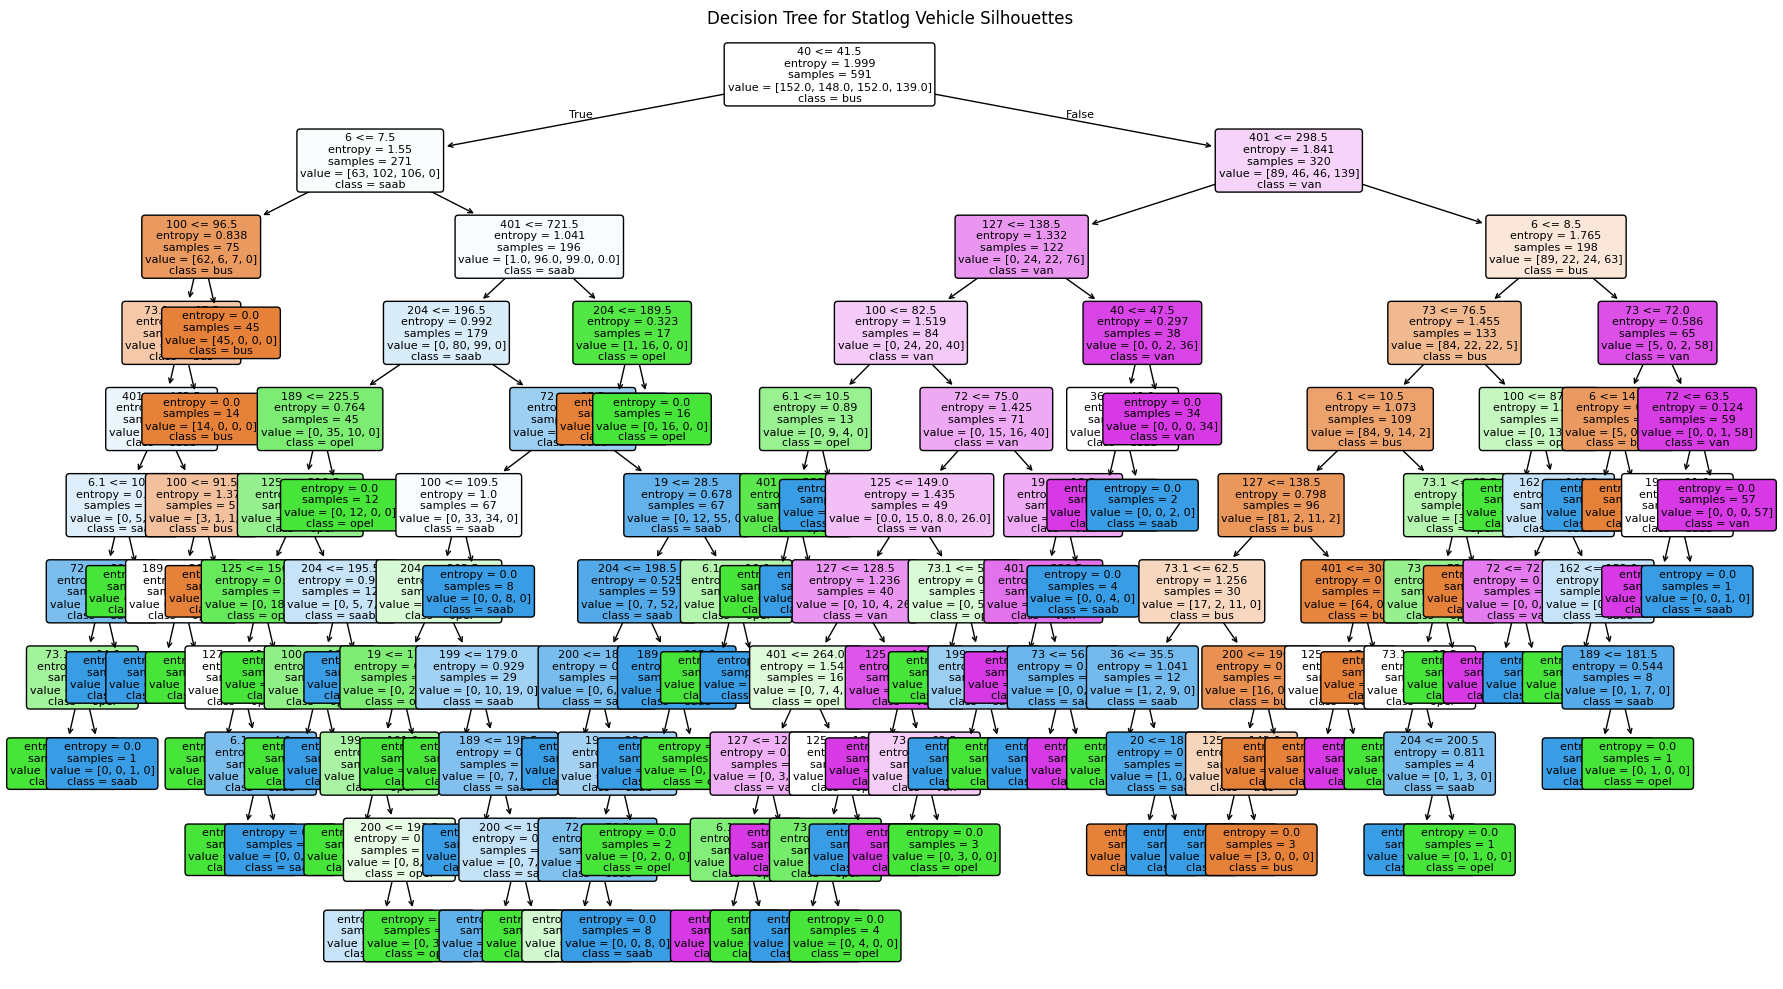

In [40]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(18, 10))
tree.plot_tree(
    best_tree,
    feature_names=feature_names,
    class_names=sorted(vehicles[vehicles.columns[-1]].unique()),
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Decision Tree for Statlog Vehicle Silhouettes")
plt.tight_layout()
plt.show()